In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train =  pd.read_csv("")

In [ ]:
from google.colab import files

# Upload your CSV file
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [ ]:
# Assuming you uploaded 'my_data.csv'
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Display the first 5 rows of the DataFrame
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#finding null values
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

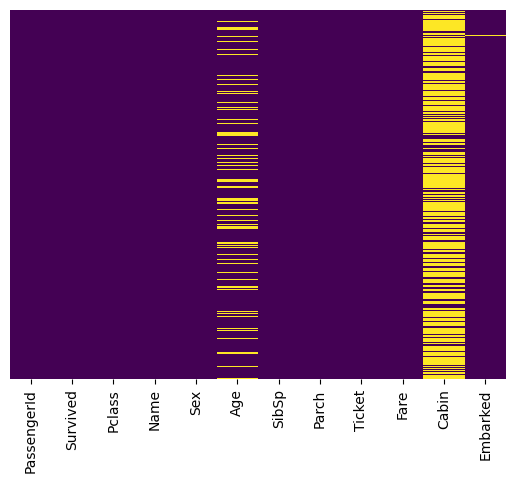

In [ ]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

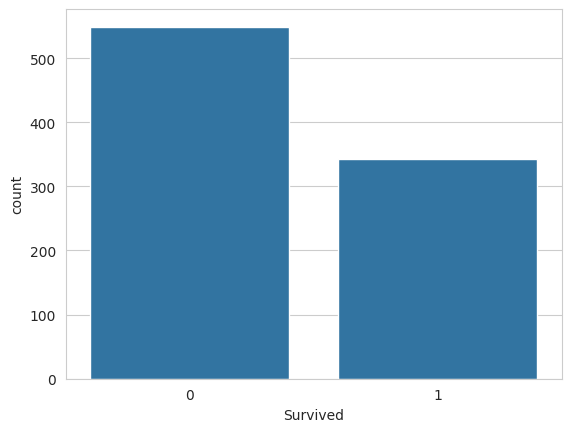

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=df)


<Axes: xlabel='Survived', ylabel='count'>

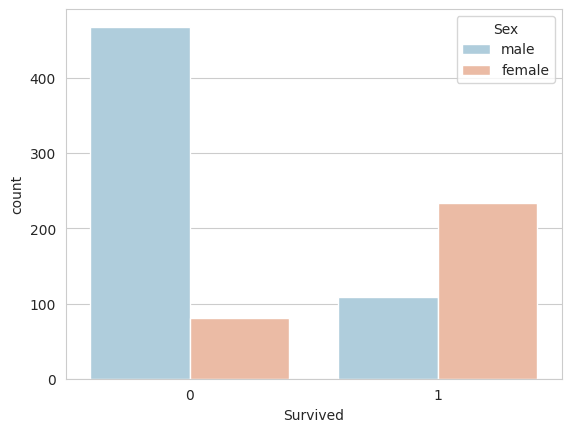

In [ ]:
sns.set_style("whitegrid")
sns.countplot(x="Survived", hue='Sex', data = df, palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

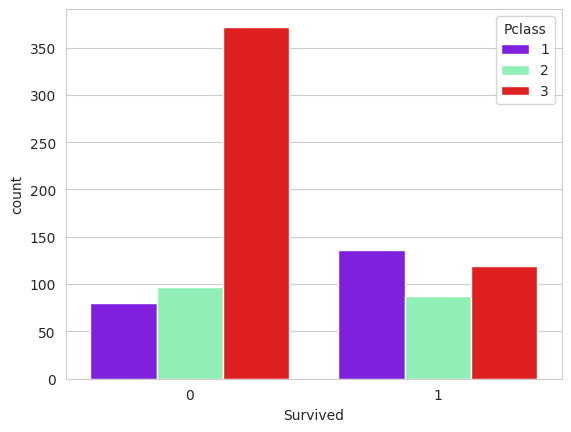

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass', data=df, palette='rainbow')

/tmp/ipykernel_2236/3706489216.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'].dropna(),kde=False,color='darkred',bins=40)


<Axes: xlabel='Age'>

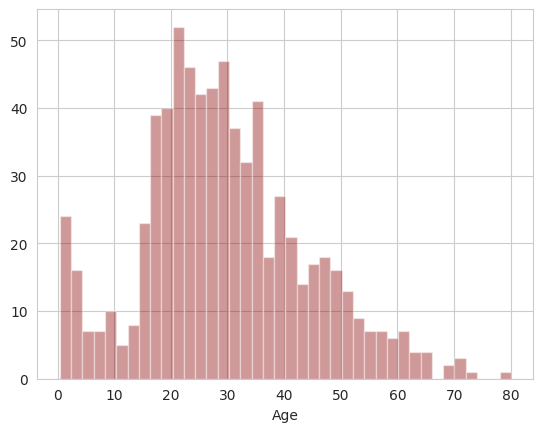

In [ ]:
sns.distplot(df['Age'].dropna(),kde=False,color='darkred',bins=40)

<Axes: >

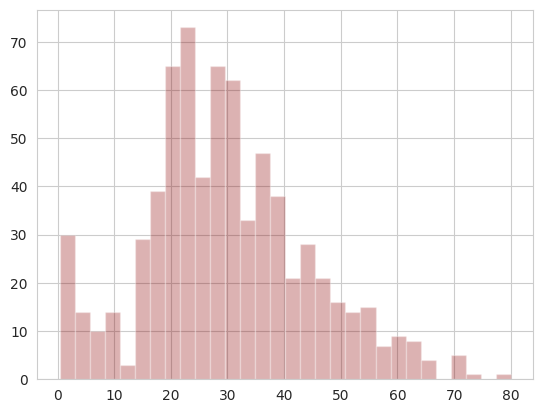

In [26]:
df['Age'].hist(bins=30,color='darkred',alpha=0.3)

<Axes: xlabel='SibSp', ylabel='count'>

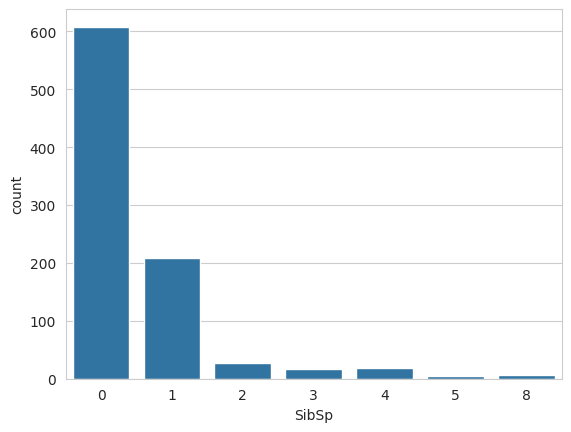

In [30]:
sns.countplot(x='SibSp',data=df)

<Axes: >

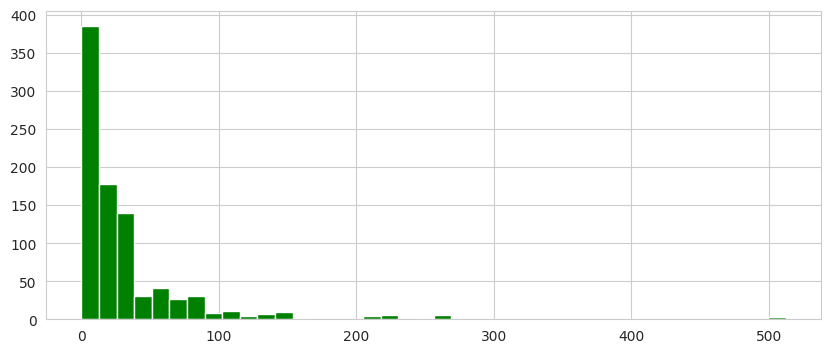

In [33]:
df['Fare'].hist(color='green',bins=40,figsize=(10,4))

/tmp/ipykernel_2236/4120833783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age',data=df, palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

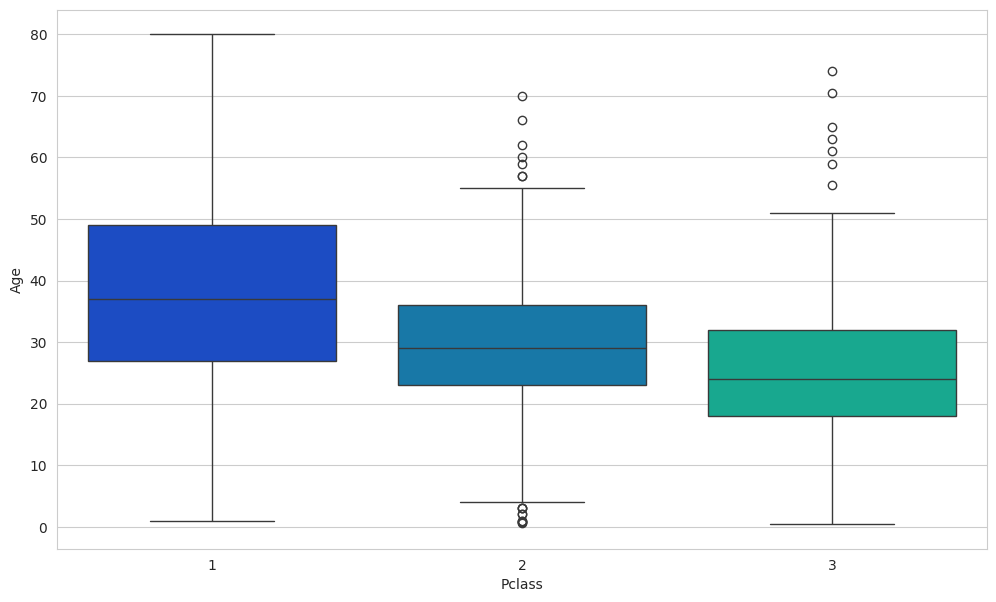

In [38]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass', y='Age',data=df, palette='winter')

In [42]:
def impute_age(cols):
  Age = cols.iloc[0]
  Pclass = cols.iloc[1]
  if pd.isnull(Age):
    if Pclass ==1:
      return 37
    elif Pclass==2:
      return 29
    else:
      return 24
  else:
    return Age

In [44]:
df['Age'] = df[['Age', 'Pclass']].apply(impute_age,axis=1)

<Axes: >

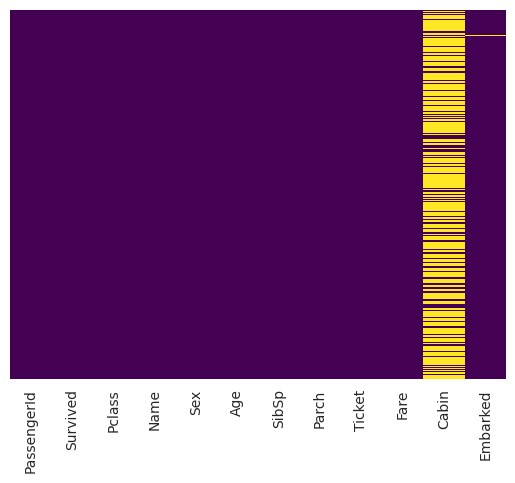

In [46]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [49]:
df.drop('Cabin',axis=1,inplace=True)

KeyError: "['Cabin'] not found in axis"

<Axes: >

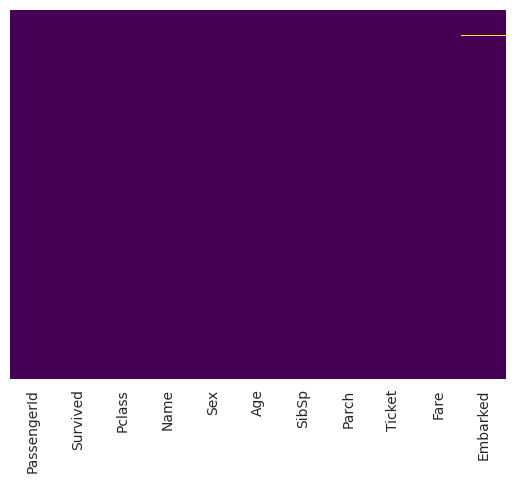

In [51]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [53]:
pd.get_dummies(df['Embarked'],drop_first=True).head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [58]:
sex = pd.get_dummies(df['Sex'],drop_first=True)
embark=pd.get_dummies(df['Embarked'],drop_first=True)

In [61]:
df.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

KeyError: "['Sex', 'Embarked', 'Name', 'Ticket'] not found in axis"

In [63]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [68]:
df=pd.concat([df,sex,embark],axis=1)

In [69]:
df.drop('Survived',axis=1).head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S,male,Q,S,male,Q,S
0,1.0,3.0,22.0,1.0,0.0,7.2500,True,False,True,True,False,True,True,False,True
1,2.0,1.0,38.0,1.0,0.0,71.2833,False,False,False,False,False,False,False,False,False
2,3.0,3.0,26.0,0.0,0.0,7.9250,False,False,True,False,False,True,False,False,True
3,4.0,1.0,35.0,1.0,0.0,53.1000,False,False,True,False,False,True,False,False,True
4,5.0,3.0,35.0,0.0,0.0,8.0500,True,False,True,True,False,True,True,False,True


In [71]:
df['Survived'].head()

,Survived
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0


In [73]:
from sklearn.model_selection import train_test_split

In [77]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Survived',axis=1),df['Survived'],test_size=0.30,random_state=101)

### Fixing `NaN` values and re-preparing data for modeling

The `ValueError` from `LogisticRegression` indicates that the training data still contains `NaN` (Not a Number) values. This is likely due to issues during the previous data cleaning and feature engineering steps, such as incorrect column drops or repeated concatenations that introduced `NaN`s or duplicate columns.

To address this, we will re-execute the data preparation from a fresh start, ensuring all `NaN` values are handled and the feature set is correctly structured before splitting the data into training and testing sets.

In [81]:
# Re-load the original data to ensure a clean DataFrame state
df_clean = pd.read_csv(file_name)

# Re-apply age imputation
df_clean['Age'] = df_clean[['Age', 'Pclass']].apply(impute_age, axis=1)

# Drop the 'Cabin' column as it has too many missing values
df_clean.drop('Cabin', axis=1, inplace=True)

# Create dummy variables for 'Sex' and 'Embarked' before dropping original columns
sex_dummies = pd.get_dummies(df_clean['Sex'], drop_first=True, dtype=int)
embark_dummies = pd.get_dummies(df_clean['Embarked'], drop_first=True, dtype=int)

# Drop the original categorical columns and non-useful identifier columns
df_clean.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

# Concatenate the new dummy variables to the DataFrame
df_clean = pd.concat([df_clean, sex_dummies, embark_dummies], axis=1)

# Verify that there are no remaining NaN values in the features
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

display(df_clean.head())


Missing values after cleaning:
Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
male        0
Q           0
S           0
dtype: int64


,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


Now that the data is clean and prepared, we can split it into training and testing sets again.

In [82]:
# Re-perform train-test split with the cleaned DataFrame
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (623, 8)
y_train shape: (623,)
X_test shape: (268, 8)
y_test shape: (268,)


In [79]:
from sklearn.linear_model import LogisticRegression

In [84]:
logmodel=LogisticRegression(max_iter=1000) # Increased max_iter for convergence if needed
logmodel.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [85]:
predictions = logmodel.predict(X_test)

In [87]:
from sklearn.metrics import confusion_matrix, classification_report

In [89]:
accuracy=confusion_matrix(y_test,predictions)

In [90]:
accuracy

array([[134,  20],
       [ 38,  76]])

In [92]:
from sklearn.metrics import accuracy_score

In [95]:
accuracy_score(y_test,predictions)

0.7835820895522388

In [96]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82       154
           1       0.79      0.67      0.72       114

    accuracy                           0.78       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



### Visualizing the Confusion Matrix

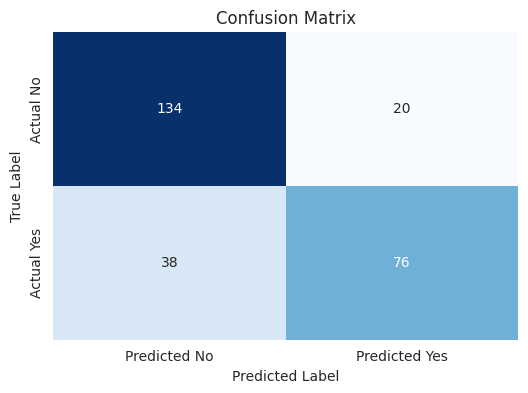

In [97]:
plt.figure(figsize=(6, 4))
sns.heatmap(accuracy, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Feature Engineering: Extracting Titles from 'Name'

In [98]:
import re

# Re-load the original data to ensure a clean DataFrame state before new feature engineering
df_feature_eng = pd.read_csv(file_name)

# Apply age imputation first, as it's a critical preprocessing step
df_feature_eng['Age'] = df_feature_eng[['Age', 'Pclass']].apply(impute_age, axis=1)

# Function to extract titles
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    # If the title exists, extract and return it.
    if title_search:
        return title_search.group(1)
    return ""

# Apply the function to create a new 'Title' column
df_feature_eng['Title'] = df_feature_eng['Name'].apply(get_title)

# Display the counts of each title to see their distribution
print("Title distribution before mapping:")
print(df_feature_eng['Title'].value_counts())

# Map rare titles to a common 'Rare' category to reduce dimensionality
df_feature_eng['Title'] = df_feature_eng['Title'].replace(['Lady', 'Countess','Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

df_feature_eng['Title'] = df_feature_eng['Title'].replace('Mlle', 'Miss')
df_feature_eng['Title'] = df_feature_eng['Title'].replace('Ms', 'Miss')
df_feature_eng['Title'] = df_feature_eng['Title'].replace('Mme', 'Mrs')

print("\nTitle distribution after mapping:")
print(df_feature_eng['Title'].value_counts())

# Display the first few rows with the new 'Title' column
display(df_feature_eng[['Name', 'Title']].head())

Title distribution before mapping:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Title distribution after mapping:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2236/2219148342.py:11: SyntaxWarning: invalid escape sequence '\.'
  title_search = re.search(' ([A-Za-z]+)\.', name)


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


### Feature Engineering: Creating Family Size and IsAlone Features

Next, let's create a `FamilySize` feature by combining `SibSp` (siblings/spouses aboard) and `Parch` (parents/children aboard), and then derive an `IsAlone` feature to indicate if a passenger was traveling alone.

In [99]:
# Create FamilySize feature
df_feature_eng['FamilySize'] = df_feature_eng['SibSp'] + df_feature_eng['Parch'] + 1 # +1 for the passenger themselves

# Create IsAlone feature
df_feature_eng['IsAlone'] = 0
df_feature_eng.loc[df_feature_eng['FamilySize'] == 1, 'IsAlone'] = 1

print("FamilySize distribution:")
print(df_feature_eng['FamilySize'].value_counts())
print("\nIsAlone distribution:")
print(df_feature_eng['IsAlone'].value_counts())

display(df_feature_eng[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head())

FamilySize distribution:
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

IsAlone distribution:
IsAlone
1    537
0    354
Name: count, dtype: int64


,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


### Re-running the Full Data Preparation Pipeline with New Features

Now that we have new features (`Title`, `FamilySize`, `IsAlone`), we need to integrate them into our data preparation pipeline. This involves dropping original categorical columns (`Sex`, `Embarked`, `Name`, `Ticket`, `PassengerId`) and the `Cabin` column again, then creating dummy variables for our new `Title` column, along with `Sex` and `Embarked`, before concatenating them all back into our DataFrame. Finally, we'll re-split the data and re-train the model.

In [100]:
# Drop the 'Cabin' column as it has too many missing values
df_feature_eng.drop('Cabin', axis=1, inplace=True)

# Create dummy variables for 'Sex', 'Embarked', and the new 'Title' column
sex_dummies_fe = pd.get_dummies(df_feature_eng['Sex'], drop_first=True, dtype=int)
embark_dummies_fe = pd.get_dummies(df_feature_eng['Embarked'], drop_first=True, dtype=int)
title_dummies_fe = pd.get_dummies(df_feature_eng['Title'], drop_first=True, dtype=int)

# Drop the original categorical columns and non-useful identifier columns
df_feature_eng.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId', 'Title'], axis=1, inplace=True)

# Concatenate the new dummy variables and engineered features to the DataFrame
df_feature_eng = pd.concat([df_feature_eng, sex_dummies_fe, embark_dummies_fe, title_dummies_fe], axis=1)

# Verify that there are no remaining NaN values in the features
print("Missing values after new feature engineering and cleaning:")
print(df_feature_eng.isnull().sum())

display(df_feature_eng.head())

Missing values after new feature engineering and cleaning:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
FamilySize    0
IsAlone       0
male          0
Q             0
S             0
Miss          0
Mr            0
Mrs           0
Rare          0
dtype: int64


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,male,Q,S,Miss,Mr,Mrs,Rare
0,0,3,22.0,1,0,7.2500,2,0,1,0,1,0,1,0,0
1,1,1,38.0,1,0,71.2833,2,0,0,0,0,0,0,1,0
2,1,3,26.0,0,0,7.9250,1,1,0,0,1,1,0,0,0
3,1,1,35.0,1,0,53.1000,2,0,0,0,1,0,0,1,0
4,0,3,35.0,0,0,8.0500,1,1,1,0,1,0,1,0,0


### Re-splitting the Data and Re-training the Model

With our newly engineered features, we'll now re-split the data into training and testing sets and then re-train the Logistic Regression model to see if our changes have improved accuracy.

In [101]:
# Re-perform train-test split with the new, feature-engineered DataFrame
X_fe = df_feature_eng.drop('Survived', axis=1)
y_fe = df_feature_eng['Survived']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.30, random_state=101)

print("X_train_fe shape:", X_train_fe.shape)
print("y_train_fe shape:", y_train_fe.shape)
print("X_test_fe shape:", X_test_fe.shape)
print("y_test_fe shape:", y_test_fe.shape)

X_train_fe shape: (623, 14)
y_train_fe shape: (623,)
X_test_fe shape: (268, 14)
y_test_fe shape: (268,)


In [102]:
# Re-train the Logistic Regression model with the new feature-engineered data
logmodel_fe = LogisticRegression(max_iter=1000)
logmodel_fe.fit(X_train_fe, y_train_fe)

# Make predictions with the re-trained model
predictions_fe = logmodel_fe.predict(X_test_fe)

print("Model re-trained and predictions made.")

Model re-trained and predictions made.


### Re-evaluating the Model with Feature-Engineered Data

Let's check the accuracy, classification report, and confusion matrix for our model with the newly engineered features.

Accuracy Score with Feature Engineering:
0.8022388059701493

Classification Report with Feature Engineering:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       154
           1       0.82      0.68      0.75       114

    accuracy                           0.80       268
   macro avg       0.81      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



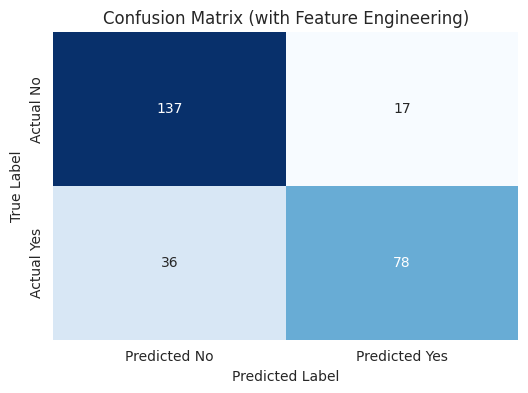

In [103]:
print("Accuracy Score with Feature Engineering:")
print(accuracy_score(y_test_fe, predictions_fe))

print("\nClassification Report with Feature Engineering:")
print(classification_report(y_test_fe, predictions_fe))

accuracy_fe = confusion_matrix(y_test_fe, predictions_fe)

plt.figure(figsize=(6, 4))
sns.heatmap(accuracy_fe, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (with Feature Engineering)')
plt.show()

### Exploring a New Model: Random Forest Classifier

Let's try a more robust model, the Random Forest Classifier, which is an ensemble learning method that can often provide better accuracy and handle non-linear relationships in the data.

In [106]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier with some default parameters
# (we can tune these later if needed)
rf_model = RandomForestClassifier(n_estimators=100, random_state=101, max_features='sqrt', min_samples_leaf=1, min_samples_split=2)

# Train the model on the feature-engineered training data
rf_model.fit(X_train_fe, y_train_fe)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


### Evaluating the Random Forest Model

Now, let's evaluate the performance of our newly trained Random Forest Classifier on the test set.

Accuracy Score with Random Forest:
0.8022388059701493

Classification Report with Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       154
           1       0.80      0.71      0.75       114

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



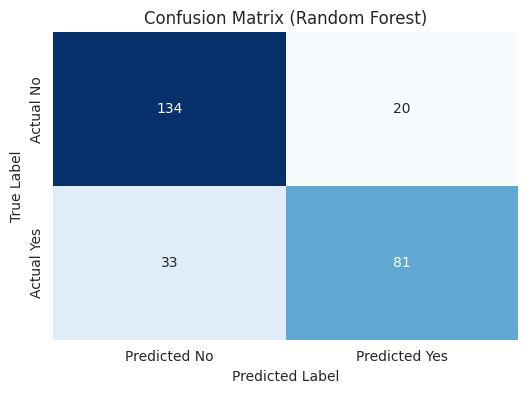

In [107]:
# Make predictions with the Random Forest model
predictions_rf = rf_model.predict(X_test_fe)

# Evaluate the Random Forest model
print("Accuracy Score with Random Forest:")
print(accuracy_score(y_test_fe, predictions_rf))

print("\nClassification Report with Random Forest:")
print(classification_report(y_test_fe, predictions_rf))

accuracy_rf = confusion_matrix(y_test_fe, predictions_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(accuracy_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

### Addressing Convergence Warning: Feature Scaling and Re-tuning Logistic Regression

To address the `ConvergenceWarning` and potentially improve model stability and performance, we will scale our features using `StandardScaler` and then re-run `GridSearchCV`.

In [108]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled = scaler.transform(X_test_fe)

print("Features scaled successfully.")
# Display a snippet of the scaled data to confirm
print("\nFirst 5 rows of scaled X_train_fe:")
print(X_train_scaled[:5])

Features scaled successfully.

First 5 rows of scaled X_train_fe:
[[-1.59418307  0.08582773 -0.49131049 -0.48432517  1.39097165 -0.57703644
   0.84074331 -1.35821532 -0.30177525  0.62003584  1.92865159 -1.16996636
  -0.39748279 -0.17248787]
 [ 0.81936748  0.00903846 -0.49131049 -0.48432517 -0.52170584 -0.57703644
   0.84074331  0.73626029  3.31372437 -1.61280999 -0.51849697  0.85472543
  -0.39748279 -0.17248787]
 [-0.38740779 -1.21958996 -0.49131049  0.72261315 -0.25961883  0.0211228
  -1.18942368 -1.35821532 -0.30177525  0.62003584  1.92865159 -1.16996636
  -0.39748279 -0.17248787]
 [ 0.81936748 -0.22132937 -0.49131049 -0.48432517 -0.51780241 -0.57703644
   0.84074331 -1.35821532 -0.30177525  0.62003584  1.92865159 -1.16996636
  -0.39748279 -0.17248787]
 [ 0.81936748 -1.91069344 -0.49131049  0.72261315 -0.39530852  0.0211228
  -1.18942368 -1.35821532 -0.30177525 -1.61280999  1.92865159 -1.16996636
  -0.39748279 -0.17248787]]


### Re-running GridSearchCV with Scaled Data

Now that our features are scaled, let's re-run `GridSearchCV` to find the best hyperparameters for the Logistic Regression model on this scaled data.

In [109]:
# Re-define the parameter grid to search (can adjust if needed, but keeping same for direct comparison)
param_grid_scaled = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'max_iter': [2000] # Increased max_iter to give more room for convergence
}

# Create a Logistic Regression model instance
logmodel_grid_scaled = LogisticRegression()

# Create GridSearchCV object with scaled data
grid_search_scaled = GridSearchCV(logmodel_grid_scaled, param_grid_scaled, cv=5, verbose=1, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the scaled training data
grid_search_scaled.fit(X_train_scaled, y_train_fe)

# Print the best parameters and best score
print("\nBest Parameters found by GridSearchCV (Scaled Data):", grid_search_scaled.best_params_)
print("Best Cross-Validation Accuracy (Scaled Data):", grid_search_scaled.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters found by GridSearchCV (Scaled Data): {'C': 10, 'max_iter': 2000, 'solver': 'liblinear'}
Best Cross-Validation Accuracy (Scaled Data): 0.8411225806451613


### Evaluating the Re-tuned Model with Scaled Data

Finally, let's evaluate the performance of the Logistic Regression model using the best parameters found with the scaled data on our scaled test set.

Accuracy Score with Scaled & Tuned Model:
0.8171641791044776

Classification Report with Scaled & Tuned Model:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       154
           1       0.83      0.72      0.77       114

    accuracy                           0.82       268
   macro avg       0.82      0.80      0.81       268
weighted avg       0.82      0.82      0.81       268



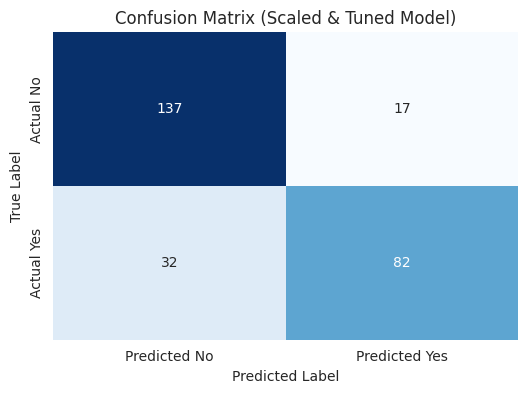

In [110]:
# Get the best model from GridSearchCV (trained on scaled data)
best_logmodel_scaled = grid_search_scaled.best_estimator_

# Make predictions with the best model on the scaled test data
predictions_tuned_scaled = best_logmodel_scaled.predict(X_test_scaled)

# Evaluate the re-tuned model
print("Accuracy Score with Scaled & Tuned Model:")
print(accuracy_score(y_test_fe, predictions_tuned_scaled))

print("\nClassification Report with Scaled & Tuned Model:")
print(classification_report(y_test_fe, predictions_tuned_scaled))

accuracy_tuned_scaled = confusion_matrix(y_test_fe, predictions_tuned_scaled)

plt.figure(figsize=(6, 4))
sns.heatmap(accuracy_tuned_scaled, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Scaled & Tuned Model)')
plt.show()

### Hyperparameter Tuning for Random Forest Classifier

Now, let's perform hyperparameter tuning for the `RandomForestClassifier` using `GridSearchCV`. This will help us find the best combination of parameters to optimize its performance on our feature-engineered and scaled data.

In [111]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10, None], # None means nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create a RandomForestClassifier instance
rf_model_grid = RandomForestClassifier(random_state=101)

# Create GridSearchCV object
grid_search_rf = GridSearchCV(rf_model_grid, param_grid_rf, cv=5, verbose=1, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the scaled training data
grid_search_rf.fit(X_train_scaled, y_train_fe)

# Print the best parameters and best score
print("\nBest Parameters found by GridSearchCV for Random Forest:", grid_search_rf.best_params_)
print("Best Cross-Validation Accuracy for Random Forest:", grid_search_rf.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters found by GridSearchCV for Random Forest: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy for Random Forest: 0.8266580645161291


### Evaluating the Tuned Random Forest Model

Let's evaluate the performance of the Random Forest model with the best parameters found by GridSearchCV.

Accuracy Score with Tuned Random Forest Model:
0.8097014925373134

Classification Report with Tuned Random Forest Model:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       154
           1       0.84      0.68      0.75       114

    accuracy                           0.81       268
   macro avg       0.82      0.79      0.80       268
weighted avg       0.81      0.81      0.81       268



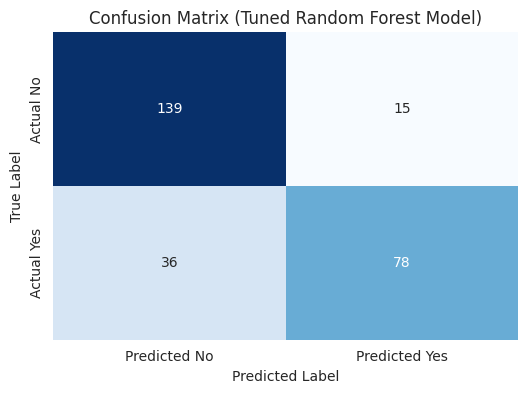

In [112]:
# Get the best Random Forest model from GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

# Make predictions with the best Random Forest model on the scaled test data
predictions_rf_tuned = best_rf_model.predict(X_test_scaled)

# Evaluate the tuned Random Forest model
print("Accuracy Score with Tuned Random Forest Model:")
print(accuracy_score(y_test_fe, predictions_rf_tuned))

print("\nClassification Report with Tuned Random Forest Model:")
print(classification_report(y_test_fe, predictions_rf_tuned))

accuracy_rf_tuned = confusion_matrix(y_test_fe, predictions_rf_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(accuracy_rf_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned Random Forest Model)')
plt.show()

### Exploring a New Model: XGBoost Classifier

Let's try a Gradient Boosting model, specifically XGBoost, known for its high performance and efficiency.

In [113]:
from xgboost import XGBClassifier

# Initialize the XGBoost Classifier
# Using some reasonable default parameters, can be tuned later
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=101)

# Train the model on the scaled and feature-engineered training data
xgb_model.fit(X_train_scaled, y_train_fe)

print("XGBoost Classifier trained successfully.")

XGBoost Classifier trained successfully.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:58:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Evaluating the XGBoost Model

Now, let's evaluate the performance of our newly trained XGBoost Classifier on the test set.

Accuracy Score with XGBoost:
0.8171641791044776

Classification Report with XGBoost:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       154
           1       0.86      0.68      0.76       114

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.81       268
weighted avg       0.82      0.82      0.81       268



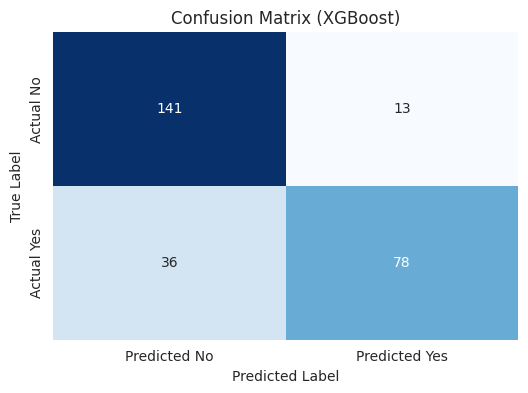

In [114]:
# Make predictions with the XGBoost model
predictions_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the XGBoost model
print("Accuracy Score with XGBoost:")
print(accuracy_score(y_test_fe, predictions_xgb))

print("\nClassification Report with XGBoost:")
print(classification_report(y_test_fe, predictions_xgb))

accuracy_xgb = confusion_matrix(y_test_fe, predictions_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(accuracy_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (XGBoost)')
plt.show()

### Hyperparameter Tuning for XGBoost Classifier

Now, let's fine-tune the XGBoost Classifier using `GridSearchCV` to find the optimal combination of hyperparameters for our dataset.

In [115]:
from xgboost import XGBClassifier

# Define the parameter grid for XGBoost Classifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Create an XGBClassifier instance
xgb_model_grid = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=101)

# Create GridSearchCV object
grid_search_xgb = GridSearchCV(xgb_model_grid, param_grid_xgb, cv=5, verbose=1, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the scaled training data
grid_search_xgb.fit(X_train_scaled, y_train_fe)

# Print the best parameters and best score
print("\nBest Parameters found by GridSearchCV for XGBoost:", grid_search_xgb.best_params_)
print("Best Cross-Validation Accuracy for XGBoost:", grid_search_xgb.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best Parameters found by GridSearchCV for XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best Cross-Validation Accuracy for XGBoost: 0.8363225806451613


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:10:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Evaluating the Tuned XGBoost Model

Let's evaluate the performance of the XGBoost model with the best parameters found by GridSearchCV.

Accuracy Score with Tuned XGBoost Model:
0.8171641791044776

Classification Report with Tuned XGBoost Model:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       154
           1       0.85      0.69      0.76       114

    accuracy                           0.82       268
   macro avg       0.82      0.80      0.81       268
weighted avg       0.82      0.82      0.81       268



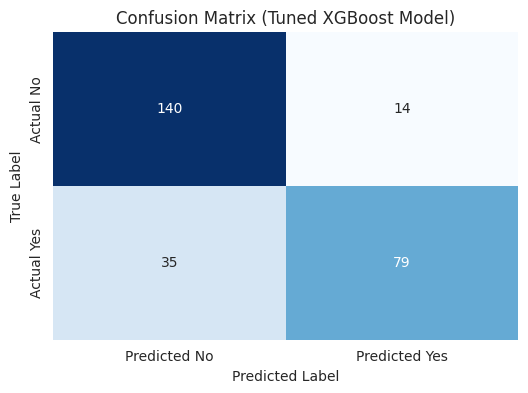

In [116]:
# Get the best XGBoost model from GridSearchCV
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions with the best XGBoost model on the scaled test data
predictions_xgb_tuned = best_xgb_model.predict(X_test_scaled)

# Evaluate the tuned XGBoost model
print("Accuracy Score with Tuned XGBoost Model:")
print(accuracy_score(y_test_fe, predictions_xgb_tuned))

print("\nClassification Report with Tuned XGBoost Model:")
print(classification_report(y_test_fe, predictions_xgb_tuned))

accuracy_xgb_tuned = confusion_matrix(y_test_fe, predictions_xgb_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(accuracy_xgb_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned XGBoost Model)')
plt.show()

### Hyperparameter Tuning with GridSearchCV

Now, let's use `GridSearchCV` to find the optimal hyperparameters for our `LogisticRegression` model. This helps in fine-tuning the model for better performance.

In [104]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'max_iter': [1000]
}

# Create a Logistic Regression model instance
logmodel_grid = LogisticRegression()

# Create GridSearchCV object
grid_search = GridSearchCV(logmodel_grid, param_grid, cv=5, verbose=1, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the training data (with feature engineering)
grid_search.fit(X_train_fe, y_train_fe)

# Print the best parameters and best score
print("\nBest Parameters found by GridSearchCV:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters found by GridSearchCV: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8411225806451613


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluating the Tuned Model

Let's evaluate the performance of the Logistic Regression model with the best parameters found by GridSearchCV.

Accuracy Score with Tuned Model:
0.8134328358208955

Classification Report with Tuned Model:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       154
           1       0.83      0.71      0.76       114

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



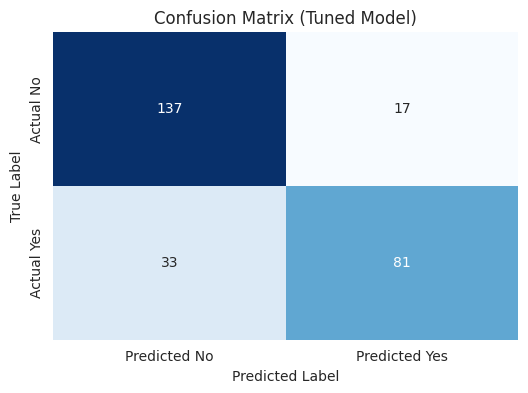

In [105]:
# Get the best model from GridSearchCV
best_logmodel = grid_search.best_estimator_

# Make predictions with the best model
predictions_tuned = best_logmodel.predict(X_test_fe)

# Evaluate the tuned model
print("Accuracy Score with Tuned Model:")
print(accuracy_score(y_test_fe, predictions_tuned))

print("\nClassification Report with Tuned Model:")
print(classification_report(y_test_fe, predictions_tuned))

accuracy_tuned = confusion_matrix(y_test_fe, predictions_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(accuracy_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()